# Tugas Kuliah PCD 03
Nama    : Syafiq Syadidul Azmi <br>
NIM     : G6401231075 <br>
Paralel : 3

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [111]:
hawar_daun = cv2.imread('hawar-daun.png')
chlorosis = cv2.imread('begomovirus.jpg')

In [112]:
def rgb_to_hsv(img):

    img = img.astype(np.float32) / 255.0
    B = img[:,:,0]
    G = img[:,:,1]
    R = img[:,:,2]

    Cmax = np.maximum(np.maximum(R, G), B)
    Cmin = np.minimum(np.minimum(R, G), B)
    delta = Cmax - Cmin

    H = np.zeros_like(Cmax)
    S = np.zeros_like(Cmax)
    V = Cmax

    # Hue
    mask = delta != 0

    idx = (Cmax == R) & mask
    H[idx] = (60 * ((G[idx] - B[idx]) / delta[idx]) % 360)

    idx = (Cmax == G) & mask
    H[idx] = (60 * ((B[idx] - R[idx]) / delta[idx]) + 120)

    idx = (Cmax == B) & mask
    H[idx] = (60 * ((R[idx] - G[idx]) / delta[idx]) + 240)

    # Saturation
    S[Cmax != 0] = delta[Cmax != 0] / Cmax[Cmax != 0]

    H = (H / 2).astype(np.uint8)     
    S = (S * 255).astype(np.uint8)
    V = (V * 255).astype(np.uint8)

    hsv = np.stack([H,S,V], axis=2)
    return hsv

In [113]:
def rgb_to_lab(img):

    img = img.astype(np.float32) / 255.0
    B = img[:,:,0]
    G = img[:,:,1]
    R = img[:,:,2]

    # RGB → XYZ
    X = 0.4124*R + 0.3576*G + 0.1805*B
    Y = 0.2126*R + 0.7152*G + 0.0722*B
    Z = 0.0193*R + 0.1192*G + 0.9505*B

    # Fungsi f(t)
    def f(t):
        mask = t > 0.008856
        t[mask] = t[mask] ** (1/3)
        t[~mask] = (7.787 * t[~mask]) + (16/116)
        return t

    fx = f(X)
    fy = f(Y)
    fz = f(Z)

    L = (116 * fy) - 16
    a = 500 * (fx - fy)
    b = 200 * (fy - fz)

    # Scaling ke 0-255
    L = (L * 255 / 100)
    a = a + 128
    b = b + 128

    lab = np.stack([L, a, b], axis=2)
    lab = np.clip(lab, 0, 255).astype(np.uint8)

    return lab

## Chlorosis

In [114]:
chlorosis_lab = rgb_to_lab(chlorosis)
L_channel, a_channel, b_channel = cv2.split(chlorosis_lab)

chlorosis_hsv = rgb_to_hsv(chlorosis)
H_channel, S_channel, V_channel = cv2.split(chlorosis_hsv)

lab histogram

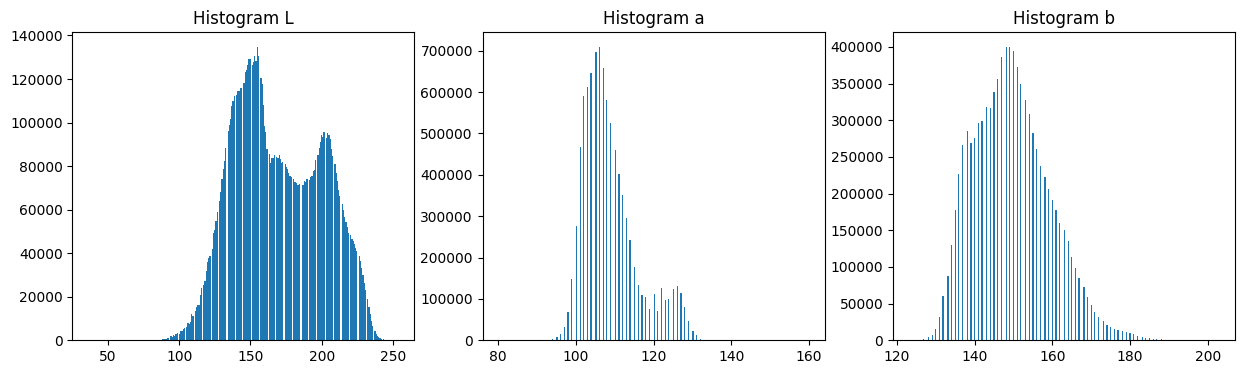

In [115]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(L_channel.ravel(), bins=256)
plt.title("Histogram L")

plt.subplot(1,3,2)
plt.hist(a_channel.ravel(), bins=256)
plt.title("Histogram a")

plt.subplot(1,3,3)
plt.hist(b_channel.ravel(), bins=256)
plt.title("Histogram b")

plt.show()

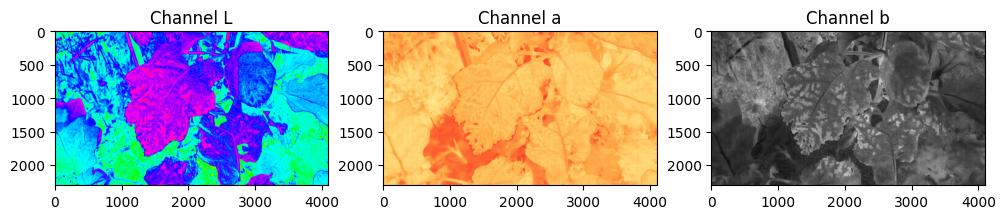

In [116]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.imshow(L_channel, cmap='hsv')  # hsv colormap biar keliatan spektrum warnanya
plt.title("Channel L")

plt.subplot(1,3,2)
plt.imshow(a_channel, cmap='YlOrRd')  # kuning ke merah, makin jenuh makin merah
plt.title("Channel a")

plt.subplot(1,3,3)
plt.imshow(b_channel, cmap='gray')  # V itu kecerahan, gray udah cukup
plt.title("Channel b")

plt.show()

hsv histogram

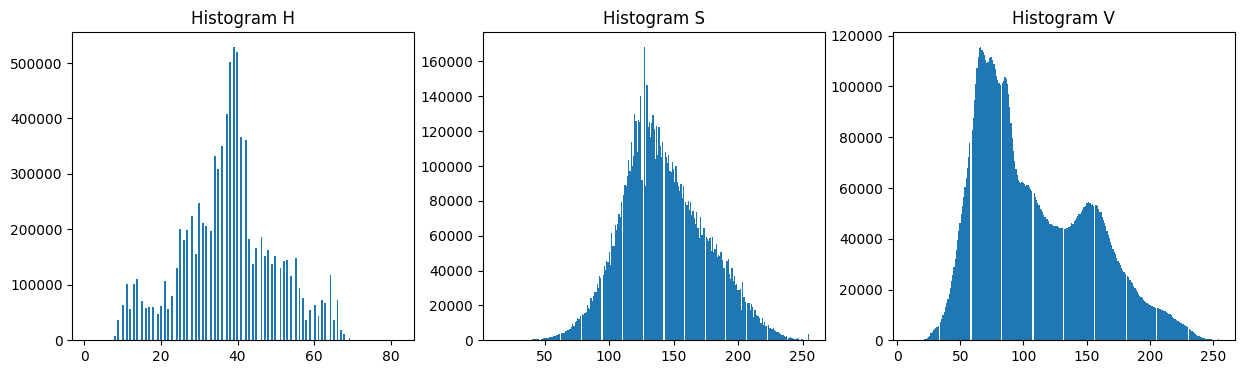

In [117]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.hist(H_channel.ravel(), bins=180)
plt.title("Histogram H")

plt.subplot(1,3,2)
plt.hist(S_channel.ravel(), bins=256)
plt.title("Histogram S")

plt.subplot(1,3,3)
plt.hist(V_channel.ravel(), bins=256)
plt.title("Histogram V")

plt.show()

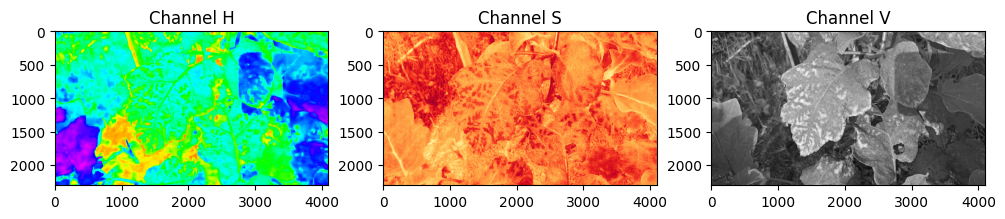

In [118]:
plt.figure(figsize=(12, 4))

plt.subplot(1,3,1)
plt.imshow(H_channel, cmap='hsv')  # hsv colormap biar keliatan spektrum warnanya
plt.title("Channel H")

plt.subplot(1,3,2)
plt.imshow(S_channel, cmap='YlOrRd')  # kuning ke merah, makin jenuh makin merah
plt.title("Channel S")

plt.subplot(1,3,3)
plt.imshow(V_channel, cmap='gray')  # V itu kecerahan, gray udah cukup
plt.title("Channel V")

plt.show()

Thresholding

In [119]:
mask_lab = (L_channel >= 180) & (b_channel >= 160)

mask_lab = mask_lab.astype(np.uint8) * 255

In [120]:
# tambahin V >= 80 biar background gelap kefilter
mask_hsv = (H_channel >= 15) & (H_channel <= 30) & (S_channel >= 50) & (V_channel >= 80)

mask_hsv = mask_hsv.astype(np.uint8) * 255

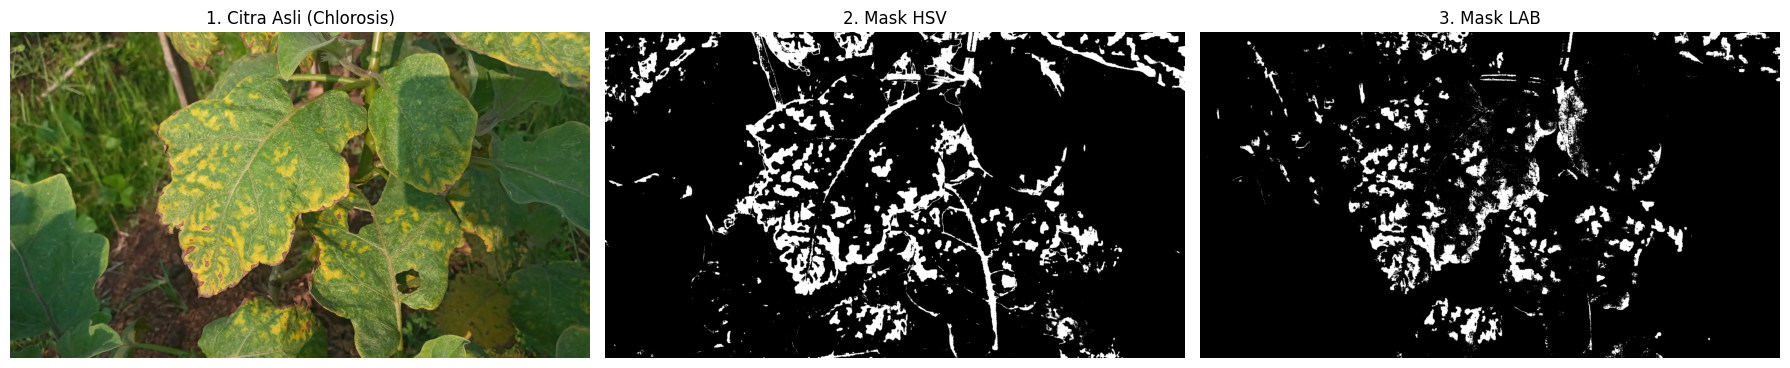

In [121]:
import matplotlib.pyplot as plt
import cv2

# Membuat layout 1 baris, 3 kolom
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Citra Asli
# OpenCV bacanya BGR, jadi harus di-convert ke RGB biar warnanya bener di plt
ax[0].imshow(cv2.cvtColor(chlorosis, cv2.COLOR_BGR2RGB))
ax[0].set_title("1. Citra Asli (Chlorosis)")
ax[0].axis("off")

# 2. Mask HSV
ax[1].imshow(mask_hsv, cmap='gray')
ax[1].set_title("2. Mask HSV")
ax[1].axis("off")

# 3. Mask LAB
ax[2].imshow(mask_lab, cmap='gray')
ax[2].set_title("3. Mask LAB")
ax[2].axis("off")

plt.tight_layout()
plt.show()